In [1]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt

IMAGES_DIR = "images"  
MAX_SIDE   = 800      
EXTS = (".jpg", ".jpeg", ".png", ".webp", ".bmp", ".tif", ".tiff")

def find_image(stem):
    if not os.path.isdir(IMAGES_DIR):
        return None
    for f in sorted(os.listdir(IMAGES_DIR)):
        name, ext = os.path.splitext(f)
        if name.lower() == stem.lower() and ext.lower() in EXTS:
            return os.path.join(IMAGES_DIR, f)
    return None

def load_image(stem, max_side=MAX_SIDE, optional=False):
    path = find_image(stem)
    if path is None:
        if optional:
            return None
        raise FileNotFoundError(f"Put an image called '{stem}' (jpg/png/...) inside the '{IMAGES_DIR}' folder "
                                f"(current folder: {os.getcwd()}).")
    img = cv2.imread(path, cv2.IMREAD_COLOR)
    if img is None:
        raise ValueError(f"OpenCV could not read {path}")
    s = max_side / max(img.shape[:2])
    if s < 1:
        img = cv2.resize(img, None, fx=s, fy=s, interpolation=cv2.INTER_AREA)
    print(f"loaded {os.path.basename(path)}: {img.shape[1]}x{img.shape[0]} px")
    return img

def show(imgs, titles, figsize=(14, 5)):
    plt.figure(figsize=figsize)
    for i, (im, t) in enumerate(zip(imgs, titles), 1):
        plt.subplot(1, len(imgs), i)
        if im.ndim == 3:
            plt.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
        else:
            plt.imshow(im, cmap="gray")
        plt.title(t); plt.axis("off")
    plt.tight_layout(); plt.show()

def grid_view(img, title="", step=50, figsize=(10, 7)):
    h, w = img.shape[:2]
    plt.figure(figsize=figsize)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.xticks(range(0, w, step), rotation=90); plt.yticks(range(0, h, step))
    plt.grid(True, color="yellow", alpha=0.6, linewidth=0.6)
    plt.title(title); plt.show()

def center_square(img, side):
    h, w = img.shape[:2]; s = min(h, w)
    y0, x0 = (h - s) // 2, (w - s) // 2
    return cv2.resize(img[y0:y0 + s, x0:x0 + s], (side, side), interpolation=cv2.INTER_AREA)

def border_color(img, k=10):
    patches = [img[:k, :k], img[:k, -k:], img[-k:, :k], img[-k:, -k:]]
    return tuple(int(v) for v in np.median(np.concatenate([p.reshape(-1, 3) for p in patches]), axis=0))

def T(tx, ty):
    return np.array([[1, 0, tx], [0, 1, ty], [0, 0, 1]], float)

def S(sx, sy):
    return np.array([[sx, 0, 0], [0, sy, 0], [0, 0, 1]], float)

def R(deg):
    t = np.deg2rad(deg); c, s = np.cos(t), np.sin(t)
    return np.array([[c, -s, 0], [s, c, 0], [0, 0, 1]], float)

def warp(img, M3, size, border=(0, 0, 0), flags=cv2.INTER_LINEAR):
    return cv2.warpAffine(img, M3[:2].astype(np.float64), size, flags=flags, borderValue=border)

def warp_p(img, H, size, border=(0, 0, 0)):
    return cv2.warpPerspective(img, H.astype(np.float64), size, borderValue=border)

def homography_4pts(src, dst):
    A, b = [], []
    for (x, y), (u, v) in zip(src, dst):
        A.append([x, y, 1, 0, 0, 0, -u * x, -u * y]); b.append(u)
        A.append([0, 0, 0, x, y, 1, -v * x, -v * y]); b.append(v)
    h = np.linalg.solve(np.array(A, float), np.array(b, float))
    return np.append(h, 1).reshape(3, 3)

def poly(img, pts, color):
    cv2.fillPoly(img, [np.round(np.array(pts)).astype(np.int32).reshape(-1, 1, 2)], color)

def paste_layer(base, art, M, persp=False):
    f = warp_p if persp else warp
    size = (base.shape[1], base.shape[0])
    wa = f(art, M, size); mk = f(np.full(art.shape[:2], 255, np.uint8), M, size)
    out = base.copy(); out[mk > 127] = wa[mk > 127]
    return out

---
## Task 1: The Tiny Fingerprint

loaded Task 01.png: 631x800 px
2x2 scale matrix:
 [[3. 0.]
 [0. 3.]]
centering shift t = c - A c = [-400. -400.]
centre maps to: [200. 200.] (should equal [200. 200.] )


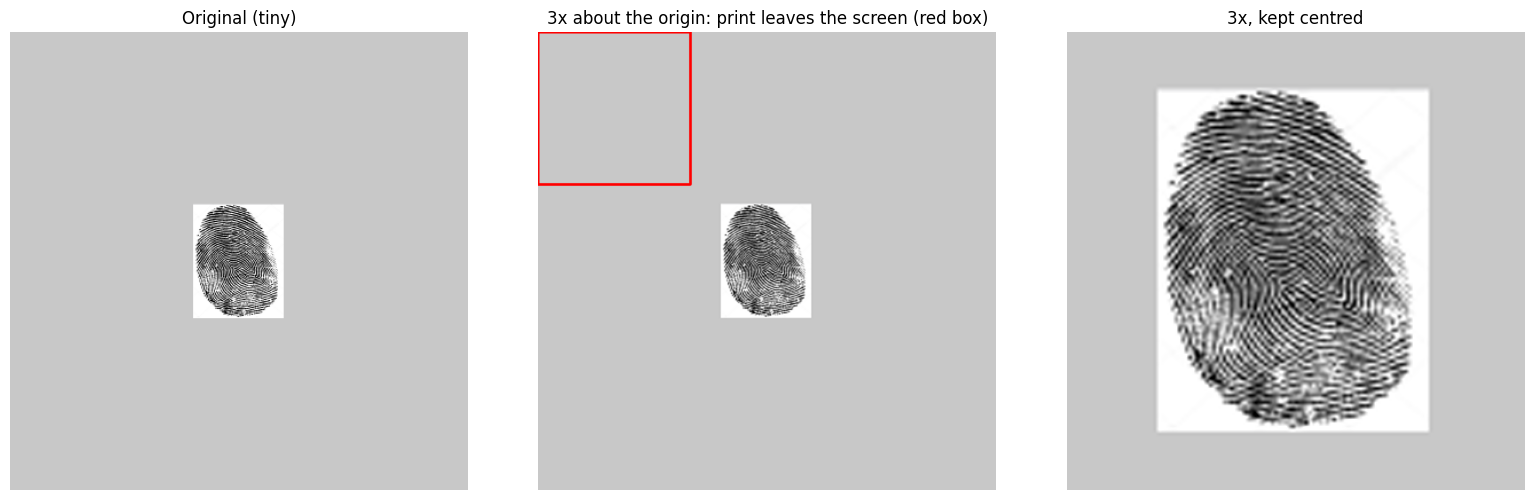

In [2]:
fp = load_image("Task 01")

SCREEN = 400
scr_bg = (200, 200, 200)
k = 100 / max(fp.shape[:2])
tiny = cv2.resize(fp, None, fx=k, fy=k, interpolation=cv2.INTER_AREA)
img = np.full((SCREEN, SCREEN, 3), scr_bg, np.uint8)
y0, x0 = (SCREEN - tiny.shape[0]) // 2, (SCREEN - tiny.shape[1]) // 2
img[y0:y0 + tiny.shape[0], x0:x0 + tiny.shape[1]] = tiny

h, w = img.shape[:2]
c = np.array([w / 2, h / 2])

sx = sy = 3.0
A = np.array([[sx, 0], [0, sy]])                 
t = c - A @ c                                    
M_naive    = np.hstack([A, np.zeros((2, 1))])
M_centered = np.hstack([A, t.reshape(2, 1)])
print("2x2 scale matrix:\n", A)
print("centering shift t = c - A c =", t)
print("centre maps to:", A @ c + t, "(should equal", c, ")")

naive    = cv2.warpAffine(img, M_naive, (int(w * sx), int(h * sy)), flags=cv2.INTER_CUBIC, borderValue=scr_bg)
centered = cv2.warpAffine(img, M_centered, (w, h), flags=cv2.INTER_CUBIC, borderValue=scr_bg)
cv2.rectangle(naive, (0, 0), (w - 1, h - 1), (0, 0, 255), 6)   
show([img, naive, centered], ["Original (tiny)", "3x about the origin: print leaves the screen (red box)", "3x, kept centred"], (16, 5))

---
## Task 2: The Dizzy Satellite

loaded Task 02.png: 691x505 px
Rotation matrix (45 deg):
 [[ 0.7071 -0.7071]
 [ 0.7071  0.7071]]
Tilted size: (846, 846) -> new canvas size: (1197, 1197)


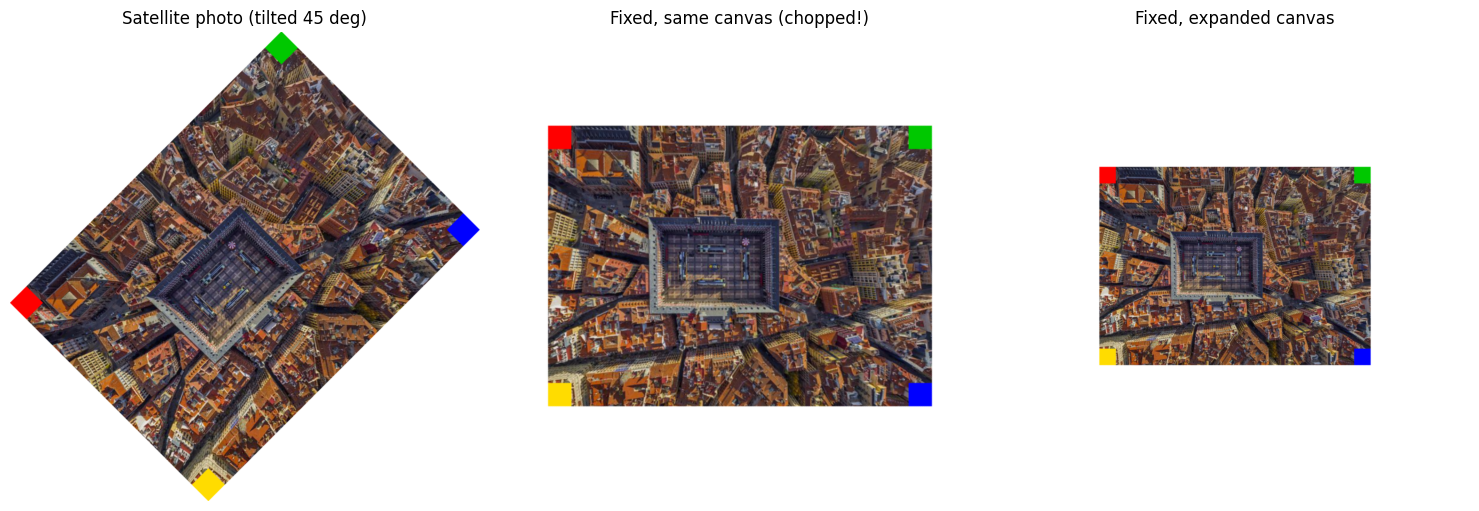

In [3]:
ALREADY_TILTED = False     
TILT_DEG = 45       

def mark_corners(img, size=None):
    img = img.copy(); h, w = img.shape[:2]; s = size or max(12, min(h, w) // 12)
    for (x, y), col in [((0, 0), (0, 0, 255)), ((w - s, 0), (0, 200, 0)), ((w - s, h - s), (255, 0, 0)), ((0, h - s), (0, 220, 255))]:
        cv2.rectangle(img, (x, y), (x + s - 1, y + s - 1), col, -1)
    return img

def rotate_expand(img, deg, border=(0, 0, 0)):
    h, w = img.shape[:2]
    th = np.deg2rad(deg)
    Rm = np.array([[np.cos(th), -np.sin(th)], [np.sin(th), np.cos(th)]])         
    new_w = int(np.ceil(h * abs(np.sin(th)) + w * abs(np.cos(th))))
    new_h = int(np.ceil(h * abs(np.cos(th)) + w * abs(np.sin(th))))
    t = np.array([new_w / 2, new_h / 2]) - Rm @ np.array([w / 2, h / 2])       
    M = np.hstack([Rm, t.reshape(2, 1)])
    return cv2.warpAffine(img, M, (new_w, new_h), borderValue=border), Rm, (new_w, new_h)

WHITE = (255, 255, 255)
city = mark_corners(load_image("Task 02"))
tilted = city if ALREADY_TILTED else rotate_expand(city, -TILT_DEG, WHITE)[0]  

h, w = tilted.shape[:2]
th = np.deg2rad(TILT_DEG)
Rm = np.array([[np.cos(th), -np.sin(th)], [np.sin(th), np.cos(th)]])
t0 = np.array([w / 2, h / 2]) - Rm @ np.array([w / 2, h / 2])
chopped = cv2.warpAffine(tilted, np.hstack([Rm, t0.reshape(2, 1)]), (w, h), borderValue=WHITE)

fixed, Rm, size = rotate_expand(tilted, TILT_DEG, WHITE)
print(f"Rotation matrix ({TILT_DEG} deg):\n", np.round(Rm, 4))
print("Tilted size:", (w, h), "-> new canvas size:", size)
show([tilted, chopped, fixed], [f"Satellite photo (tilted {TILT_DEG} deg)", "Fixed, same canvas (chopped!)", "Fixed, expanded canvas"], (15, 5))

---
## Task 3: The Fast Train Barcode

loaded Task 03.png: 790x442 px
2x2 shear matrix:
 [[1.  0.4]
 [0.  1. ]]
Mean abs difference vs. original barcode: 2.854


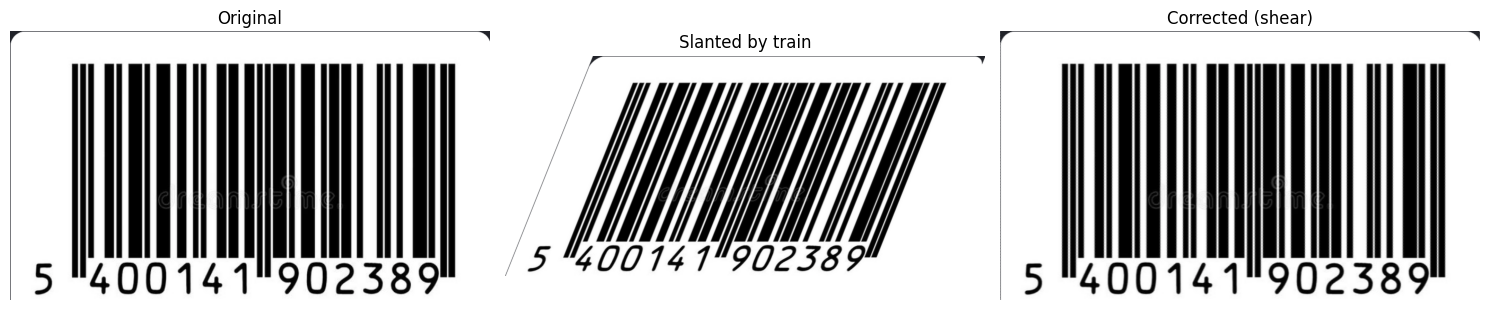

In [4]:
barcode = load_image("Task 03")
h, w = barcode.shape[:2]
k = 0.4
bg = border_color(barcode)

Mslant = np.array([[1, -k, k * h], [0, 1, 0]], float)
Ws = w + int(k * h)
slanted = cv2.warpAffine(barcode, Mslant, (Ws, h), borderValue=bg)

shear = np.array([[1, k], [0, 1]])
offset = np.array([[-k * h], [0]])
M = np.hstack([shear, offset])
print("2x2 shear matrix:\n", shear)
fixed = cv2.warpAffine(slanted, M, (Ws - int(k * h), h), borderValue=bg)

diff = np.abs(fixed.astype(int) - barcode.astype(int)).mean()
print("Mean abs difference vs. original barcode:", round(diff, 3))
show([barcode, slanted, fixed], ["Original", "Slanted by train", "Corrected (shear)"], (15, 4))

---
## Task 4: The Hidden Treasure Map

loaded Task 04.png: 600x400 px
Translation matrix:
 [[  1.   0. 150.]
 [  0.   1.  80.]
 [  0.   0.   1.]]


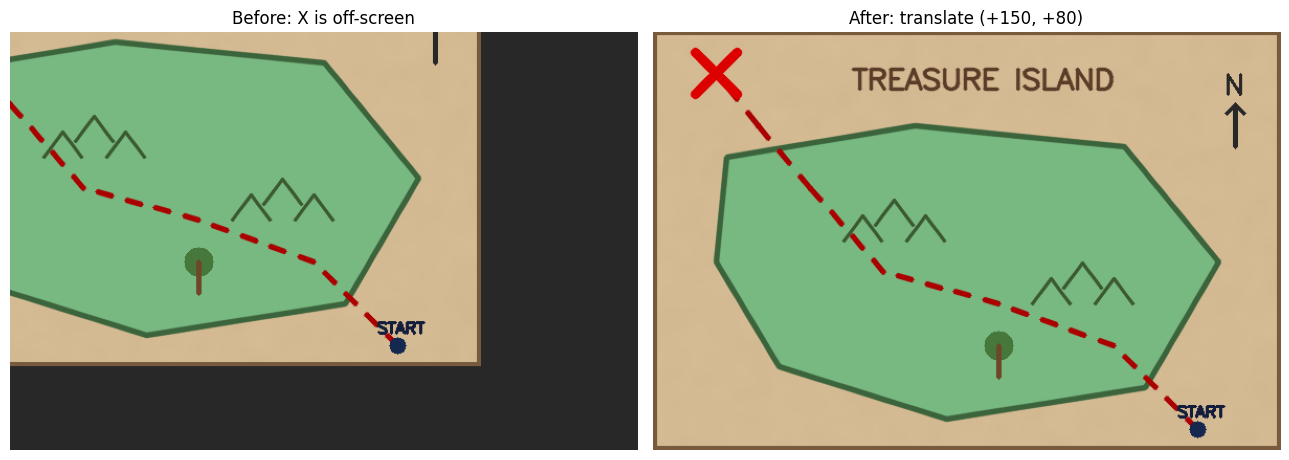

In [5]:
tmap = load_image("Task 04")
H, W = tmap.shape[:2]
tx, ty = 150, 80
m = 200                                                        

buf = np.full((H + 2 * m, W + 2 * m, 3), 40, np.uint8)       
buf[m:m + H, m:m + W] = tmap                                  

win = (slice(m + ty, m + ty + H), slice(m + tx, m + tx + W))
screen_before = buf[win]

Tm = T(tx, ty)
print("Translation matrix:\n", Tm)
shifted = warp(buf, Tm, (buf.shape[1], buf.shape[0]))
screen_after = shifted[win]
show([screen_before, screen_after], ["Before: X is off-screen", "After: translate (+150, +80)"], (13, 5))

---
## Task 5: The Robot's Assembly Line

loaded Task 05 conveyor.png: 621x622 px
loaded Task 05 chip.png: 789x643 px
Combined rigid matrix:
 [[ 3.42000e-01  9.39700e-01 -5.29299e+01]
 [-9.39700e-01  3.42000e-01  4.53675e+02]
 [ 0.00000e+00  0.00000e+00  1.00000e+00]]
det of 2x2 part: 1.0 (1 => shape preserved)


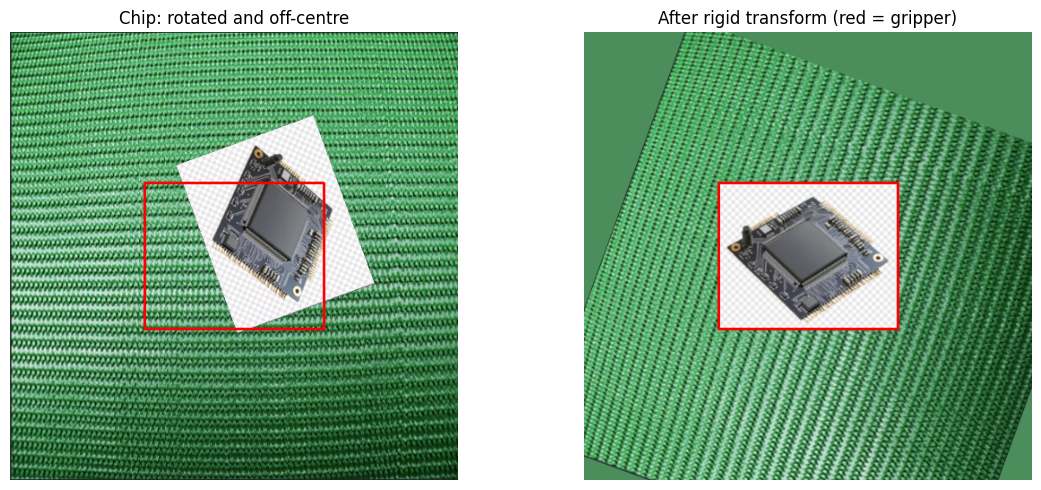

In [6]:
size = 500
ctr = np.array([size / 2, size / 2])

bg_img = load_image("Task 05 conveyor", optional=True)
board = cv2.resize(bg_img, (size, size)) if bg_img is not None else np.full((size, size, 3), (60, 90, 40), np.uint8)
bg_col = tuple(int(v) for v in board.mean((0, 1)))

chip = load_image("Task 05 chip")
kc = 200 / max(chip.shape[:2]) if max(chip.shape[:2]) > 200 else 1.0
chip = cv2.resize(chip, None, fx=kc, fy=kc, interpolation=cv2.INTER_AREA)
ch, cw = chip.shape[:2]
cy0, cx0 = int(ctr[1] - ch / 2), int(ctr[0] - cw / 2)
layer = np.zeros((size, size, 3), np.uint8); mask = np.zeros((size, size), np.uint8)
layer[cy0:cy0 + ch, cx0:cx0 + cw] = chip; mask[cy0:cy0 + ch, cx0:cx0 + cw] = 255

def comp(board, layer, mask, M3=None):
    if M3 is not None:
        layer = warp(layer, M3, board.shape[1::-1]); mask = warp(mask, M3, board.shape[1::-1])
    out = board.copy(); out[mask > 127] = layer[mask > 127]; return out

theta = 70                                             
shift = np.array([45., -35.])                           
M_forward = T(*(ctr + shift)) @ R(theta) @ T(*(-ctr))   
scene = comp(board, layer, mask, M_forward)

c_chip = ctr + shift                                  
g = ctr                                               
Rot_about_c = T(*c_chip) @ R(-theta) @ T(*(-c_chip))
M_rigid = T(*(g - c_chip)) @ Rot_about_c              
print("Combined rigid matrix:\n", np.round(M_rigid, 4))
print("det of 2x2 part:", round(np.linalg.det(M_rigid[:2, :2]), 6), "(1 => shape preserved)")

aligned = warp(scene, M_rigid, (size, size), border=bg_col)
def gripper(img):
    o = img.copy(); cv2.rectangle(o, (cx0, cy0), (cx0 + cw, cy0 + ch), (0, 0, 255), 2); return o
show([gripper(scene), gripper(aligned)], ["Chip: rotated and off-centre", "After rigid transform (red = gripper)"], (12, 5))

---
## Task 6: The Architect's Blueprint

loaded Task 06.png: 649x595 px
Similarity matrix:
 [[   1.8126    0.8452 -254.4767]
 [  -0.8452    1.8126   96.5969]
 [   0.        0.        1.    ]]
A^T A / s^2 = identity? -> [[1.0, 0.0], [0.0, 1.0]]
Equals inverse of the bad import: True


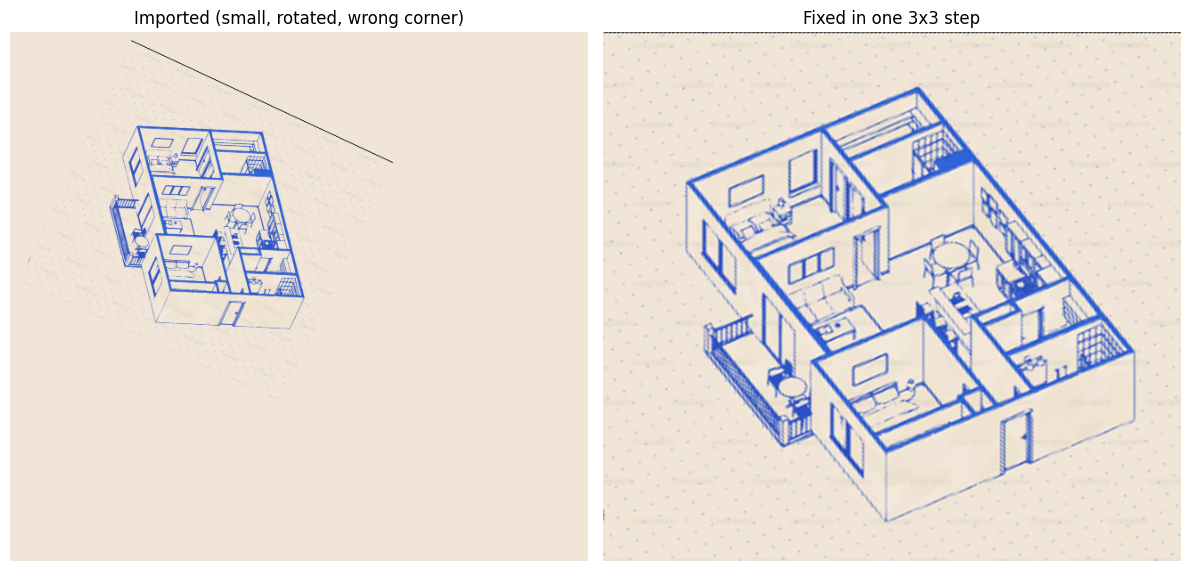

In [7]:
ideal = load_image("Task 06")
h, w = ideal.shape[:2]
paper = border_color(ideal)
ctr = np.array([w / 2, h / 2])

a = np.deg2rad(25)
half_w = 0.5 * (w / 2 * abs(np.cos(a)) + h / 2 * abs(np.sin(a)))
half_h = 0.5 * (w / 2 * abs(np.sin(a)) + h / 2 * abs(np.cos(a)))
p = np.array([half_w + 10, half_h + 10])
M_bad = T(*p) @ R(25) @ S(0.5, 0.5) @ T(*(-ctr))
bad = warp(ideal, M_bad, (w, h), border=paper)

g = ctr
M_fix = T(*g) @ R(-25) @ S(2, 2) @ T(*(-p))
print("Similarity matrix:\n", np.round(M_fix, 4))
print("A^T A / s^2 = identity? ->", np.round(M_fix[:2, :2].T @ M_fix[:2, :2] / 4, 6).tolist())
print("Equals inverse of the bad import:", np.allclose(M_fix, np.linalg.inv(M_bad)))
fixed = warp(bad, M_fix, (w, h), border=paper, flags=cv2.INTER_CUBIC)
show([bad, fixed], ["Imported (small, rotated, wrong corner)", "Fixed in one 3x3 step"], (12, 6))

---
## Task 7: The Glitched Image

loaded Task 07.png: 531x360 px
System matrix A (6x6):
 [[170.16 196.6    1.     0.     0.     0.  ]
 [  0.     0.     0.   170.16 196.6    1.  ]
 [431.34 129.55   1.     0.     0.     0.  ]
 [  0.     0.     0.   431.34 129.55   1.  ]
 [373.2  307.98   1.     0.     0.     0.  ]
 [  0.     0.     0.   373.2  307.98   1.  ]]
b: [106.2  72.  424.8  90.  265.5 288. ]

Solved affine matrix:
 [[   1.08108   -0.54054   28.51351]
 [   0.3861     1.23552 -236.60232]]
OpenCV getAffineTransform:
 [[   1.08108   -0.54054   28.51352]
 [   0.3861     1.23552 -236.60232]]
Inverse of the glitch:
 [[   1.08108   -0.54054   28.51351]
 [   0.3861     1.23552 -236.60232]]


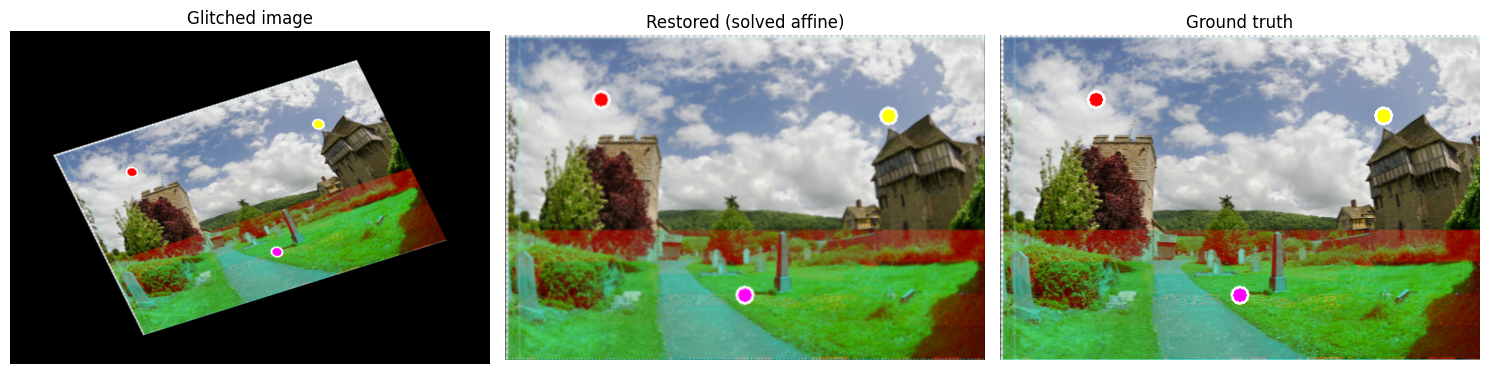

In [8]:
photo = load_image("Task 07")
h, w = photo.shape[:2]

original_pts = np.array([[0.20 * w, 0.20 * h], [0.80 * w, 0.25 * h], [0.50 * w, 0.80 * h]], float)
rad = max(6, min(h, w) // 40)
for (x, y), col in zip(original_pts, [(0, 0, 255), (0, 255, 255), (255, 0, 255)]):
    cv2.circle(photo, (int(x), int(y)), rad, col, -1); cv2.circle(photo, (int(x), int(y)), rad, (255, 255, 255), 2)

L = np.eye(3); L[:2, :2] = [[0.8, 0.35], [-0.25, 0.7]]
G = L @ T(-w / 2, -h / 2)
corners = np.array([[0, 0, 1], [w, 0, 1], [w, h, 1], [0, h, 1]], float).T
gc = (G @ corners)[:2].T
xmin, ymin = gc.min(0); xmax, ymax = gc.max(0)
G = T(-xmin + 60, -ymin + 40) @ G                                          
A_true = G[:2]
gsize = (int(np.ceil(xmax - xmin)) + 120, int(np.ceil(ymax - ymin)) + 80)
glitched = cv2.warpAffine(photo, A_true, gsize)
glitched_pts = original_pts @ A_true[:, :2].T + A_true[:, 2]               

rows, rhs = [], []
for (x, y), (u, v) in zip(glitched_pts, original_pts):                 
    rows.append([x, y, 1, 0, 0, 0]); rhs.append(u)
    rows.append([0, 0, 0, x, y, 1]); rhs.append(v)
rows = np.array(rows); rhs = np.array(rhs)
print("System matrix A (6x6):\n", np.round(rows, 2)); print("b:", np.round(rhs, 2))
M = np.linalg.solve(rows, rhs).reshape(2, 3)
print("\nSolved affine matrix:\n", np.round(M, 5))
print("OpenCV getAffineTransform:\n", np.round(cv2.getAffineTransform(glitched_pts.astype(np.float32), original_pts.astype(np.float32)), 5))
print("Inverse of the glitch:\n", np.round(np.linalg.inv(np.vstack([A_true, [0, 0, 1]]))[:2], 5))

restored = cv2.warpAffine(glitched, M, (w, h))
show([glitched, restored, photo], ["Glitched image", "Restored (solved affine)", "Ground truth"], (15, 5))

---
## Task 8: The Sidewalk Illusion

loaded Task 08 chalk art.png: 800x516 px
loaded Task 08 texture.png: 666x619 px
Manual homography:
 [[ 2.310e+00  9.100e-01 -4.935e+02]
 [ 0.000e+00  3.360e+00 -2.016e+02]
 [ 0.000e+00  4.560e-03  1.000e+00]]
max |manual - cv2.getPerspectiveTransform| = 4.440892098500626e-16


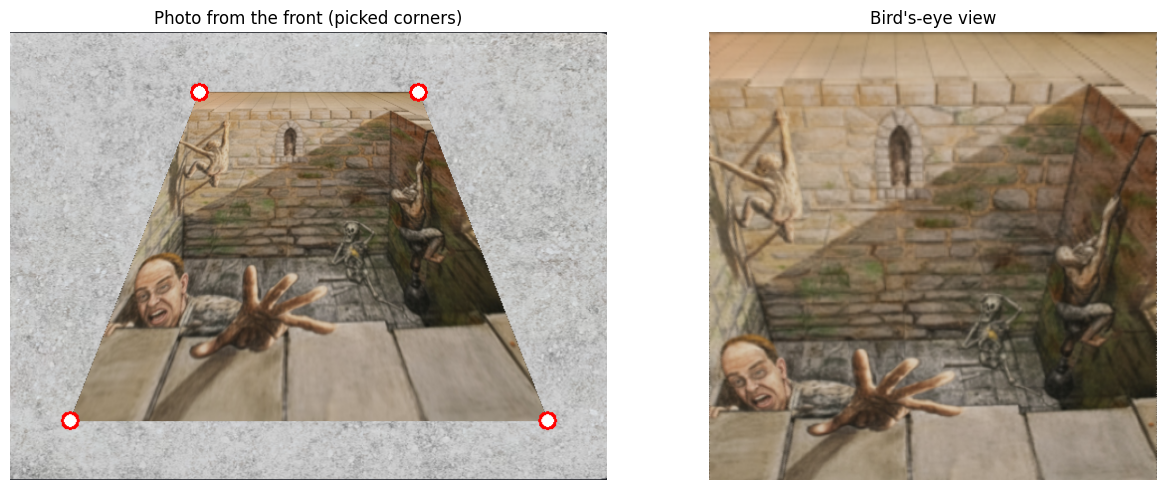

In [9]:
PICKED_CORNERS = None      
SIDE = 400                    
sq = np.float32([[0, 0], [SIDE - 1, 0], [SIDE - 1, SIDE - 1], [0, SIDE - 1]])

real = load_image("task8_photo", optional=True)
if real is not None:
    photo = real
    if PICKED_CORNERS is None:
        grid_view(photo, "Read the 4 art corners (TL, TR, BR, BL) and set PICKED_CORNERS")
        raise ValueError("Set PICKED_CORNERS = [[x,y],[x,y],[x,y],[x,y]] (TL, TR, BR, BL) and run this cell again.")
    quad = np.float32(PICKED_CORNERS)
else:
    art = center_square(load_image("Task 08 chalk art"), SIDE)
    PW, PH = 600, 450
    quad = np.float32([[190, 60], [410, 60], [540, 390], [60, 390]])      
    pave = load_image("Task 08 texture", optional=True)
    pavement = cv2.resize(pave, (PW, PH)) if pave is not None else np.full((PH, PW, 3), 120, np.uint8)
    Hf = homography_4pts(sq, quad)                                         
    photo = paste_layer(pavement, art, Hf, persp=True)

H = homography_4pts(quad, sq)
print("Manual homography:\n", np.round(H, 5))
print("max |manual - cv2.getPerspectiveTransform| =", np.abs(H - cv2.getPerspectiveTransform(quad, sq)).max())

marked = photo.copy()
for p in quad: cv2.circle(marked, tuple(int(v) for v in p), 8, (255, 255, 255), -1); cv2.circle(marked, tuple(int(v) for v in p), 8, (0, 0, 255), 2)
birdseye = warp_p(photo, H, (SIDE, SIDE))
show([marked, birdseye], ["Photo from the front (picked corners)", "Bird's-eye view"], (13, 5))

---
## Task 9: The Stadium Panorama

loaded Task 09 left.png: 406x444 px
loaded Task 09 right.png: 573x444 px
Points in photo 1:
[[333. 204.]
 [354. 225.]
 [333. 246.]
 [312. 225.]]

Points in photo 2:
[[278. 204.]
 [299. 225.]
 [278. 246.]
 [257. 225.]]

Homography (photo2 -> photo1):
 [[ 1. -0. 55.]
 [-0.  1.  0.]
 [-0. -0.  1.]]


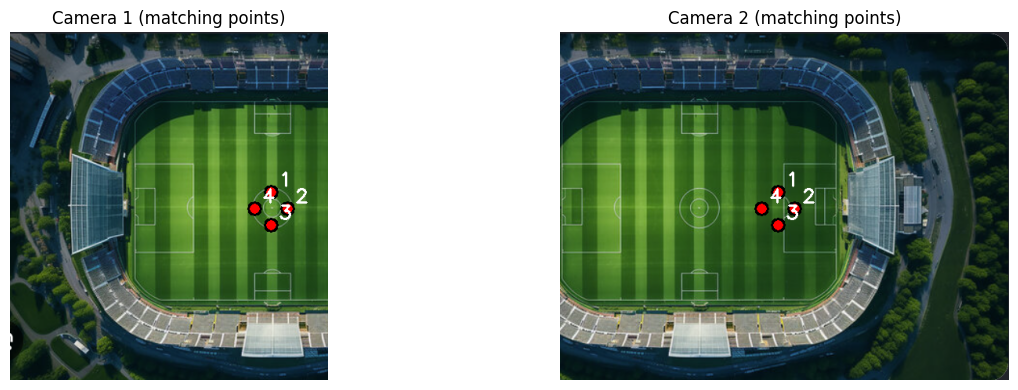

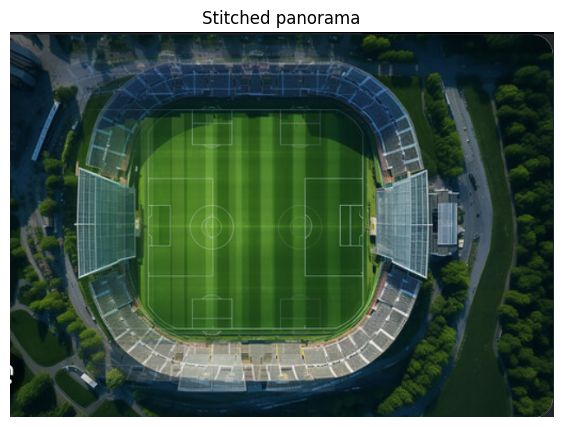

In [10]:
PTS_LEFT = np.float32([[333, 204], [354, 225], [333, 246], [312, 225]])
PTS_RIGHT = np.float32([[278, 204], [299, 225], [278, 246], [257, 225]])

def stitch(a, b, H, mask_b=None):
    ha, wa = a.shape[:2]
    hb, wb = b.shape[:2]

    corners_b = np.float32([[0, 0], [wb, 0], [wb, hb], [0, hb]])
    cb = cv2.perspectiveTransform(corners_b.reshape(-1, 1, 2), H).reshape(-1, 2)
    allp = np.vstack([cb, [[0, 0], [wa, 0], [wa, ha], [0, ha]]])

    xmin, ymin = np.floor(allp.min(0)).astype(int)
    xmax, ymax = np.ceil(allp.max(0)).astype(int)

    Tm = T(-xmin, -ymin)
    size = (int(xmax - xmin), int(ymax - ymin))

    warped = warp_p(b, Tm @ H, size)
    if mask_b is None:
        mask_b = np.full((hb, wb), 255, np.uint8)

    m2 = warp_p(mask_b, Tm @ H, size) > 250
    m2 = cv2.erode(m2.astype(np.uint8), np.ones((3, 3), np.uint8)).astype(bool)
    ox = -xmin
    oy = -ymin

    canvas1 = np.zeros_like(warped)
    m1 = np.zeros(size[::-1], bool)
    canvas1[oy:oy + ha, ox:ox + wa] = a
    m1[oy:oy + ha, ox:ox + wa] = True

    w1 = cv2.distanceTransform(m1.astype(np.uint8), cv2.DIST_L2, 3)
    w2 = cv2.distanceTransform(m2.astype(np.uint8), cv2.DIST_L2, 3)
    ws = w1 + w2
    ws[ws == 0] = 1

    pano = (canvas1 * w1[..., None] + warped * w2[..., None]) / ws[..., None]
    return np.clip(pano, 0, 255).astype(np.uint8)

left = load_image("Task 09 left", optional=True)
right = load_image("Task 09 right", optional=True)
mask2 = None
img1 = left
img2 = right

pts1 = np.float32(PTS_LEFT)
pts2 = np.float32(PTS_RIGHT)

print("Points in photo 1:")
print(np.round(pts1, 1))
print("\nPoints in photo 2:")
print(np.round(pts2, 1))

H = homography_4pts(pts2, pts1)
print("\nHomography (photo2 -> photo1):\n", np.round(H, 5))

def with_points(img, pts):
    o = img.copy()
    r = max(6, min(img.shape[:2]) // 50)
    for i, (x, y) in enumerate(pts, 1):
        cv2.circle(o, (int(x), int(y)), r, (0, 0, 255), -1)
        cv2.circle(o, (int(x), int(y)), r, (0, 0, 0), 2)
        cv2.putText(o, str(i), (int(x) + r + 2, int(y) - r), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)
    return o

pano = stitch(img1, img2, H, mask2)
show([with_points(img1, pts1), with_points(img2, pts2)], ["Camera 1 (matching points)", "Camera 2 (matching points)"], (14, 4))
plt.figure(figsize=(14, 5))
plt.imshow(cv2.cvtColor(pano, cv2.COLOR_BGR2RGB))
plt.title("Stitched panorama")
plt.axis("off")
plt.show()

---
## Task 10: The Master Forger

loaded Task 10 wall.png: 705x499 px
loaded Task 10 painting.png: 664x532 px
scale s = 0.428
S (linear):
 [[0.428 0.    0.   ]
 [0.    0.428 0.   ]
 [0.    0.    1.   ]]
Rigid:
 [[ 9.90000e-01  1.39000e-01  1.30942e+02]
 [-1.39000e-01  9.90000e-01  1.63286e+02]
 [ 0.00000e+00  0.00000e+00  1.00000e+00]]
Projective H3:
 [[ 8.066600e-01 -1.133700e-01  1.434486e+01]
 [-2.505000e-02  1.210260e+00 -9.287957e+01]
 [-7.200000e-04  1.000000e-04  1.000000e+00]]
Combined H_total:
 [[ 3.7799e-01 -0.0000e+00  1.1000e+02]
 [-8.9670e-02  5.5451e-01  1.1000e+02]
 [-3.4000e-04 -0.0000e+00  1.0000e+00]]
Direct corners->frame homography matches: True


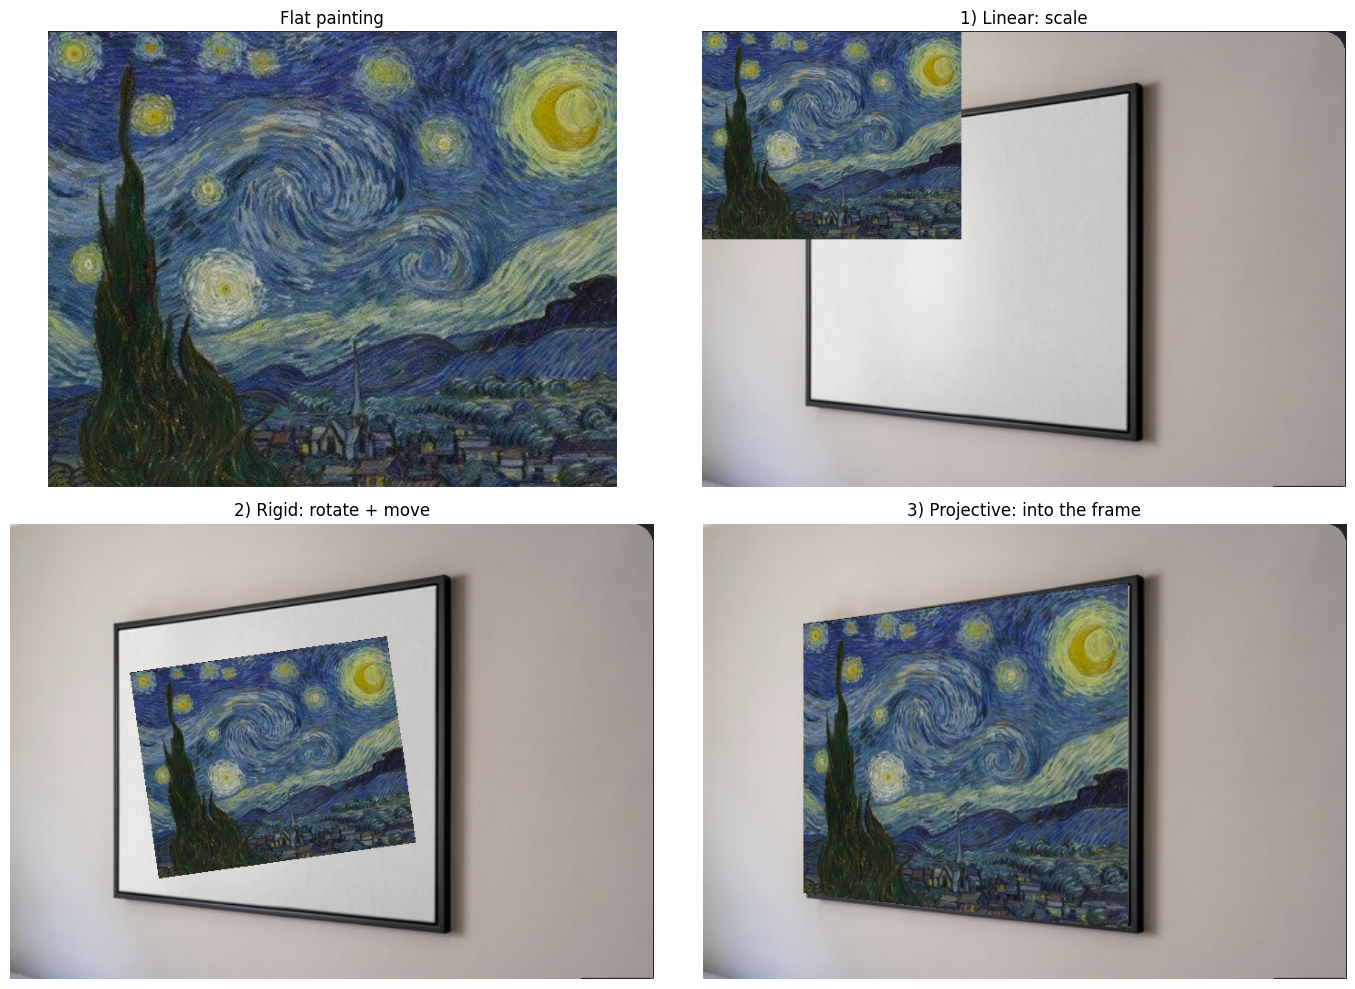

In [11]:
FRAME_QUAD = [[110, 110], [465, 65], [465, 445], [110, 405]]
SCALE = None

wall = load_image("Task 10 wall")
frame_quad = np.float32(FRAME_QUAD)
cen = frame_quad.mean(0)

painting = load_image("Task 10 painting")
ph, pw = painting.shape[:2]
corners = np.float32([[0, 0], [pw, 0], [pw, ph], [0, ph]])

fw = np.ptp(frame_quad[:, 0])
fh = np.ptp(frame_quad[:, 1])

s = (SCALE if SCALE is not None else round(min(1.0, 0.8 * min(fw / pw, fh / ph)), 3))
M_lin = S(s, s)

c_p = np.array([pw * 0.5 * s, ph * 0.5 * s])
M_rig = T(*cen) @ R(-8) @ T(*(-c_p))

moved = cv2.perspectiveTransform(corners.reshape(-1, 1, 2), M_rig @ M_lin).reshape(-1, 2)

H3 = homography_4pts(moved, frame_quad)
H_total = H3 @ M_rig @ M_lin

print("scale s =", s)
print("S (linear):\n", np.round(M_lin, 4))
print("Rigid:\n", np.round(M_rig, 3))
print("Projective H3:\n", np.round(H3, 5))
print("Combined H_total:\n", np.round(H_total / H_total[2, 2], 5))
print("Direct corners->frame homography matches:", np.allclose(H_total / H_total[2, 2], homography_4pts(corners, frame_quad), atol=1e-6))

s1 = paste_layer(wall, painting, M_lin)
s2 = paste_layer(wall, painting, M_rig @ M_lin)
final = paste_layer(wall, painting, H_total, persp=True)
plt.figure(figsize=(14, 10))

images = [painting, s1, s2, final]
titles = ["Flat painting", "1) Linear: scale", "2) Rigid: rotate + move", "3) Projective: into the frame"]
for i, (im, title) in enumerate(zip(images, titles), 1):
    plt.subplot(2, 2, i)
    plt.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()